<a href="https://colab.research.google.com/github/hiteshbalaji147-rgb/machine-learning-projects/blob/main/15_2_breast_cancer_diagnosis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project 2. Breast Cancer Diagnosis**

**Dataset:** Breast Cancer Wisconsin (Diagnostic) Data Set

**File:** `breast_cancer_dataset.csv`

**Dataset details:** https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

**1. Setup**

In [1]:
# installing the dependencies
%pip install -q numpy pandas matplotlib seaborn scikit-learn

In [2]:
# importing the dependencies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_theme(style="darkgrid")
RANDOM_STATE=42

**2. Load data**

In [4]:
# read csv data into a pandas dataframe
df = pd.read_csv("breast_cancer_dataset.csv")

In [5]:
df.shape

(569, 32)

In [6]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119
1,842517,M,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089
2,84300903,M,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088
3,84348301,M,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173
4,84358402,M,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077


In [7]:
df = df.drop(columns=["id"])

In [8]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119
1,M,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089
2,M,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088
3,M,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173
4,M,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077


**3. Exploratory Data Analysis**

In [9]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [10]:
# check presence of missing values
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [12]:
# check if there is any encoded missing values - top repeated values
for col in df.columns:
    print(df[col].value_counts().head(10))

diagnosis
B    357
M    212
Name: count, dtype: int64
radius_mean
12.340    4
11.060    3
10.260    3
12.770    3
13.050    3
13.850    3
12.180    3
11.600    3
13.000    3
11.710    3
Name: count, dtype: int64
texture_mean
16.840    3
19.830    3
15.700    3
20.520    3
18.220    3
14.930    3
18.900    3
17.460    3
16.850    3
20.130    2
Name: count, dtype: int64
perimeter_mean
82.610     3
134.700    3
87.760     3
113.400    2
120.200    2
107.100    2
79.190     2
114.200    2
58.790     2
82.690     2
Name: count, dtype: int64
area_mean
512.200     3
321.600     2
582.700     2
1138.000    2
477.300     2
372.700     2
758.600     2
559.200     2
561.000     2
641.200     2
Name: count, dtype: int64
smoothness_mean
0.101    5
0.115    4
0.105    4
0.107    4
0.106    3
0.105    3
0.095    3
0.085    3
0.117    3
0.109    3
Name: count, dtype: int64
compactness_mean
0.115    3
0.121    3
0.152    2
0.112    2
0.111    2
0.105    2
0.128    2
0.077    2
0.127    2
0.058    2
Nam

In [13]:
# identify duplicate rows
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()

print("Number of duplicate rows:", num_duplicates)
print("Duplicated row:\n",df[duplicate_mask])

# If you want to remove duplicates:
# df_no_duplicates = df.drop_duplicates()
# print("Shape after dropping duplicates:", df_no_duplicates.shape)

Number of duplicate rows: 0
Duplicated row:
 Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []


In [14]:
# class distribution
print(df["diagnosis"].value_counts())
print("-"*50)
print(df["diagnosis"].value_counts(normalize=True)*100)

diagnosis
B    357
M    212
Name: count, dtype: int64
--------------------------------------------------
diagnosis
B   62.742
M   37.258
Name: proportion, dtype: float64


In [15]:
# encode categorical column
df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})

In [16]:
# class distribution
print(df["diagnosis"].value_counts())
print("-"*50)
print(df["diagnosis"].value_counts(normalize=True)*100)

diagnosis
0    357
1    212
Name: count, dtype: int64
--------------------------------------------------
diagnosis
0   62.742
1   37.258
Name: proportion, dtype: float64


In [17]:
df.groupby("diagnosis").mean()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,12.147,17.915,78.075,462.790,0.092,0.080,0.046,0.026,0.174,0.063,0.284,1.220,2.000,21.135,0.007,0.021,0.026,0.010,0.021,0.004,13.380,23.515,87.006,558.899,0.125,0.183,0.166,0.074,0.270,0.079
1,17.463,21.605,115.365,978.376,0.103,0.145,0.161,0.088,0.193,0.063,0.609,1.211,4.324,72.672,0.007,0.032,0.042,0.015,0.020,0.004,21.135,29.318,141.370,1422.286,0.145,0.375,0.451,0.182,0.323,0.092


**Data Visualization**

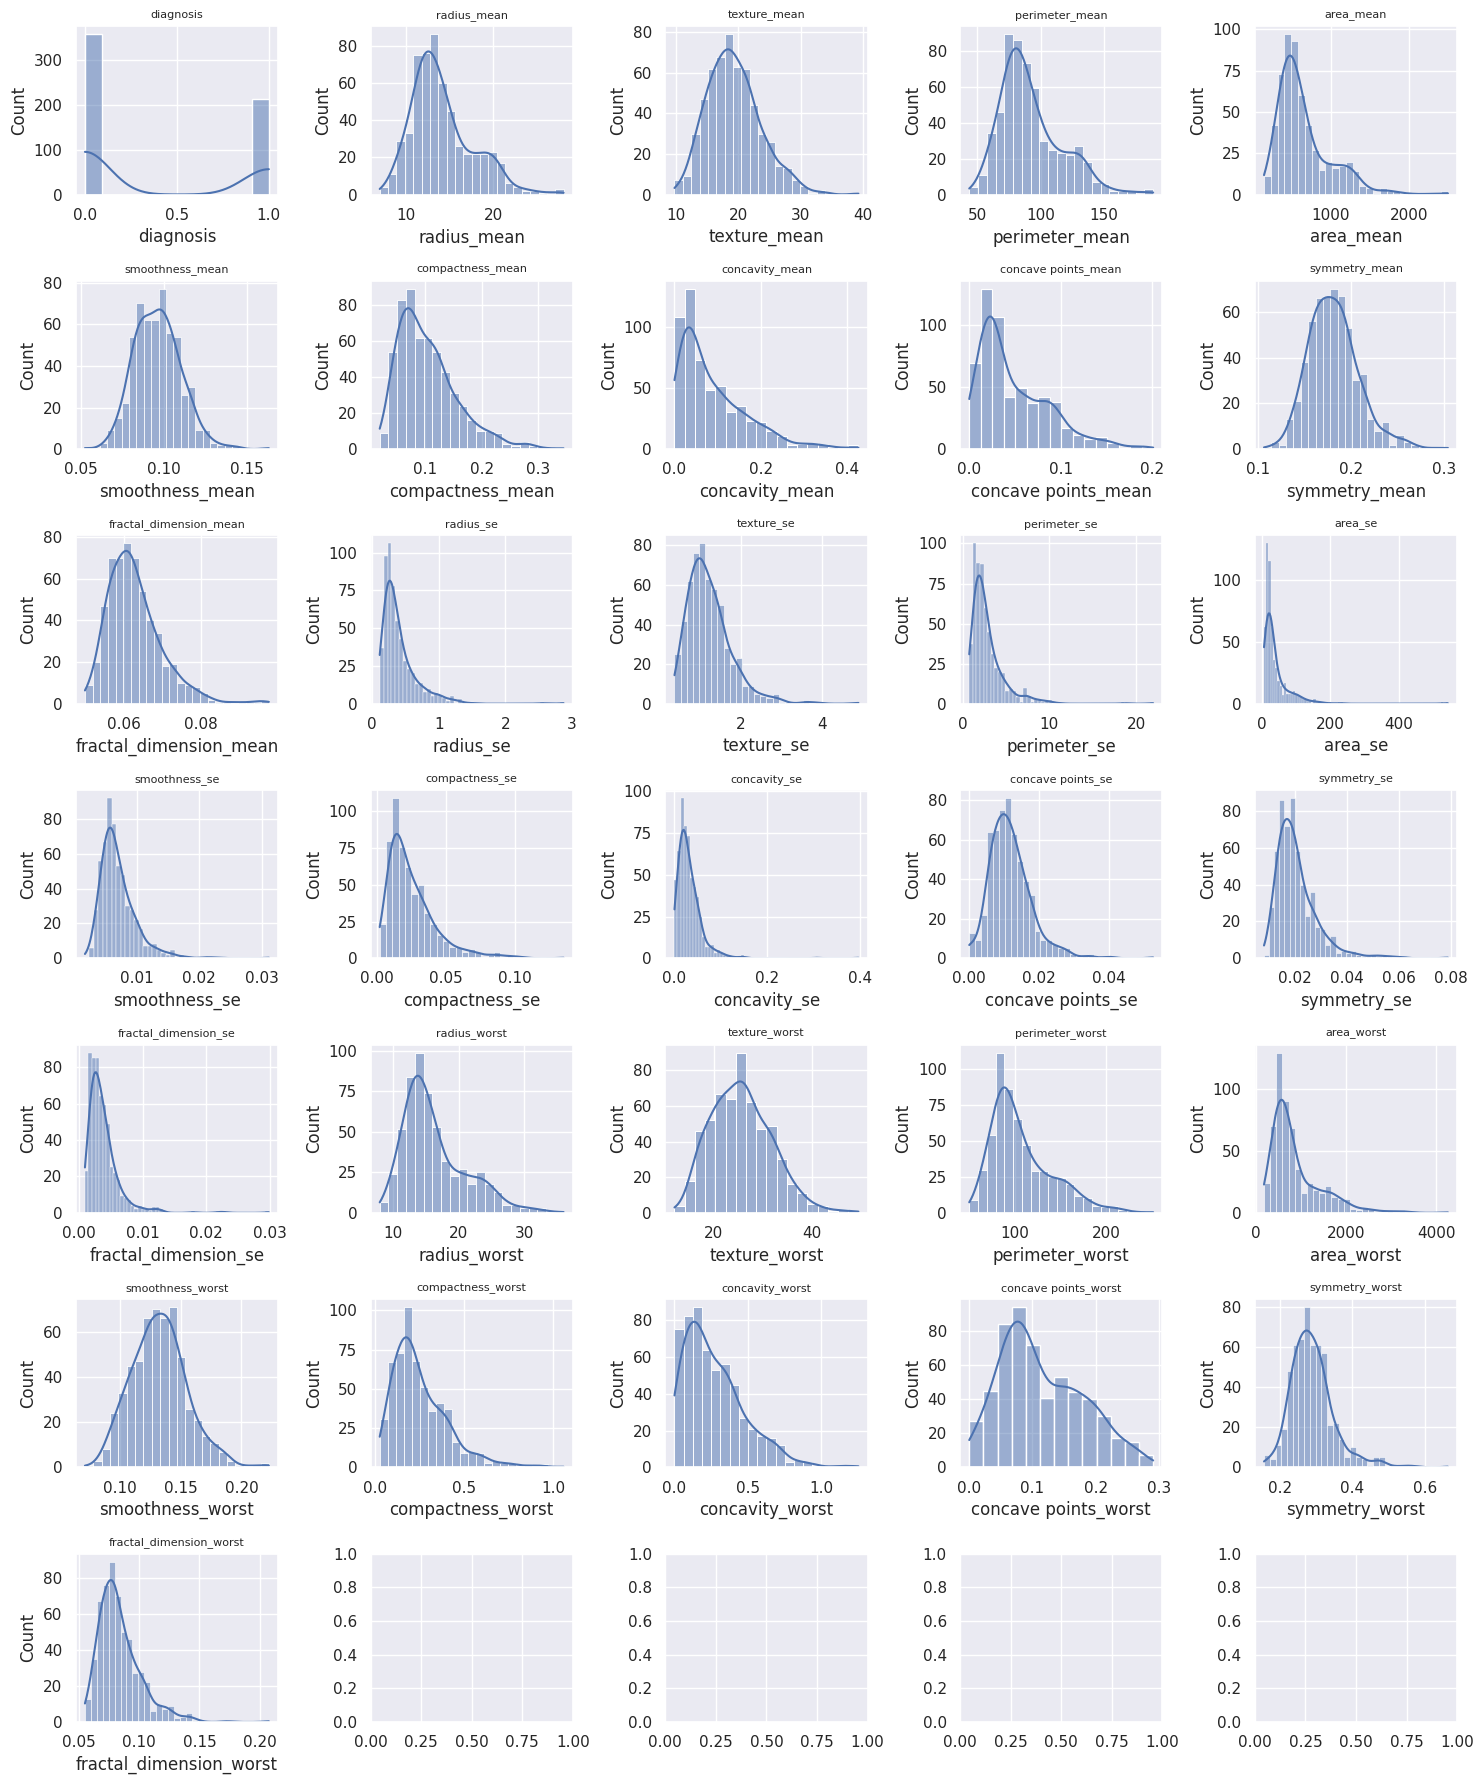

In [18]:
# histogram plot - distribution
fig, axes = plt.subplots(7, 5, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

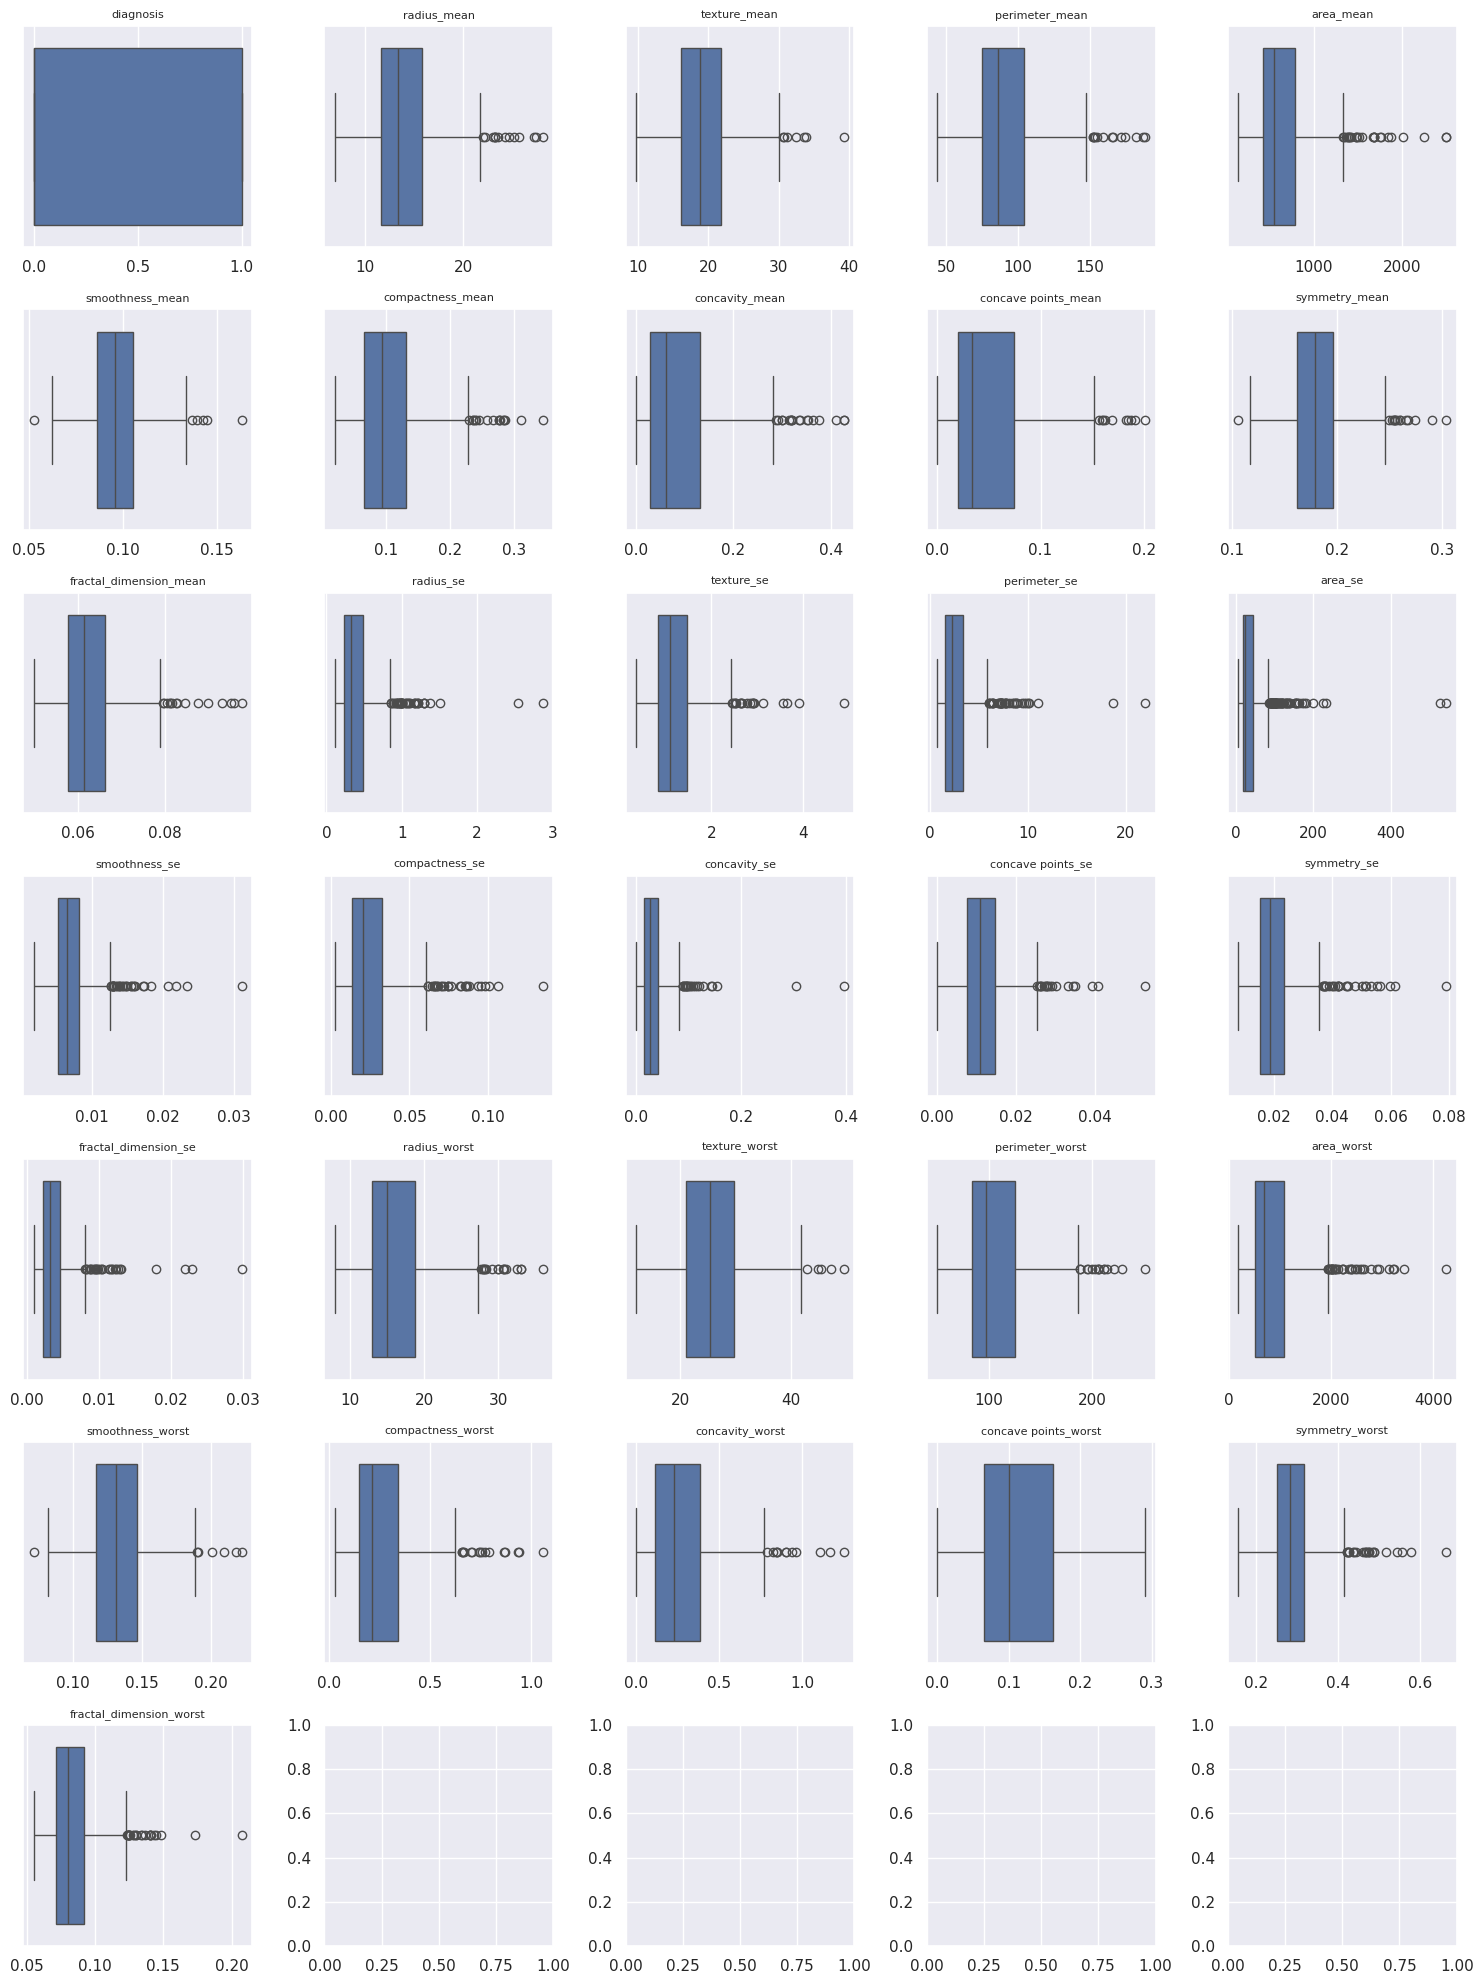

In [19]:
# outliers analysis - boxplot
fig, axes = plt.subplots(7, 5, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

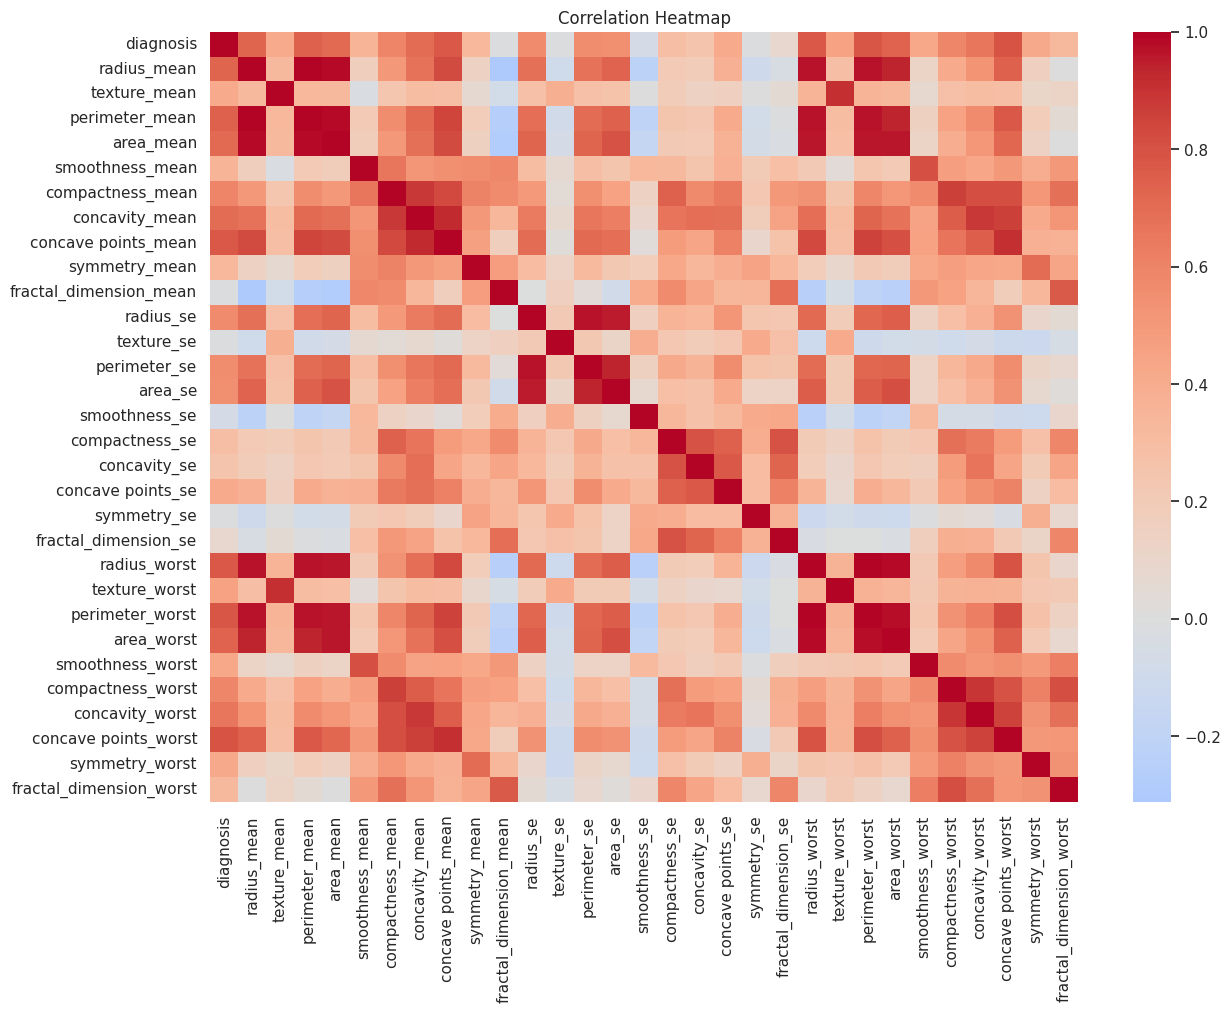

In [20]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(14, 10))
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

**Insights:**
- Drop the id column
- All features are numerical, no categorical variables
- High-dimensional feature space
- No missing values
- Slight class imbalance, address after baseline using precision and recall
- Recall is the priority metric since false negatives are critical
- Strong separation in feature means between classes
- Extreme values often represent malignant cases, not noise
- Highly correlated features present. We can perform feature selection / PCA

**4. Data Preprocessing**

In [21]:
# separate data into features and target
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [22]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [23]:
print("Dataset size", X.shape)
print("Train Dataset size", X_train.shape)
print("Test Dataset size", X_test.shape)

Dataset size (569, 30)
Train Dataset size (455, 30)
Test Dataset size (114, 30)


**5. Baseline Model - Logistic Regression**

In [24]:
scaler = StandardScaler()

In [25]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
model = LogisticRegression()

In [27]:
# training the model
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [28]:
# training accuracy
model.score(X_train_scaled, y_train)

0.9868131868131869

In [29]:
# test accuracy
model.score(X_test_scaled, y_test)

0.9649122807017544

**6. Model Optimization**

In [30]:
# pipeline creation
pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("pca", PCA()),
        ("model", SVC(kernel="rbf"))
    ]
)

In [31]:
# grid of hyperparameters
param_grid = [
    {
        "pca__n_components": [10, 15, 20, 25, 30],
        "model__C": [0.1, 1, 10, 100, 1000],
        "model__gamma": [0.001, 0.01, 0.1, 1, "scale"]
    }
]

In [32]:
# cross-validation setup (used inside grid search cv)
k=5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [33]:
# hyperparameter tuning
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="recall",
    cv=skf,
    n_jobs=-1
)

In [34]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA()), ('model', SVC())]),
             n_jobs=-1,
             param_grid=[{'model__C': [0.1, 1, 10, 100, 1000],
                          'model__gamma': [0.001, 0.01, 0.1, 1, 'scale'],
                          'pca__n_components': [10, 15, 20, 25, 30]}],
             scoring='recall')

In [35]:
print("Hyperparameter Tuning result:")
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Hyperparameter Tuning result:
Best params: {'model__C': 10, 'model__gamma': 'scale', 'pca__n_components': 10}
Best score: 0.9647058823529411


**7. Train with best params**

In [36]:
best_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=10)),
        ("model", SVC(kernel="rbf", C=10, gamma="scale"))
    ]
)

In [37]:
# train the pipeline
best_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=10)),
                ('model', SVC(C=10))])

**8. Model evaluation**

In [38]:
# training data predictions
y_train_pred = best_pipeline.predict(X_train)

In [39]:
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {round(train_acc*100, 2)} %")

Training Accuracy: 98.9 %


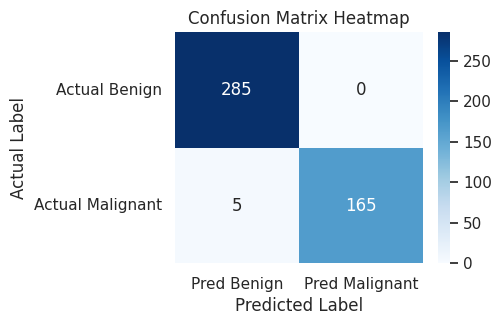

In [40]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(4,3))
# heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Benign", "Pred Malignant"],
    yticklabels=["Actual Benign", "Actual Malignant"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [41]:
print("Training Classification report")
print(classification_report(y_train, y_train_pred))

Training Classification report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       285
           1       1.00      0.97      0.99       170

    accuracy                           0.99       455
   macro avg       0.99      0.99      0.99       455
weighted avg       0.99      0.99      0.99       455



In [42]:
# test data prediction
y_test_pred = best_pipeline.predict(X_test)

In [43]:
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {round(test_acc*100, 2)} %")

Test Accuracy: 96.49 %


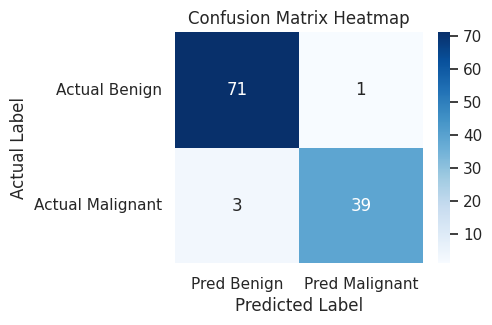

In [44]:
# confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(4,3))
# heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Benign", "Pred Malignant"],
    yticklabels=["Actual Benign", "Actual Malignant"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [45]:
print("Test Classification report")
print(classification_report(y_test, y_test_pred))

Test Classification report
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



**9. Build a predictive system**

In [46]:
def predict_cancer(input_features):
    input_df = pd.DataFrame(
        [input_features],
        columns=X_train.columns
    )
    prediction = best_pipeline.predict(input_df)
    print("Model prediction:", prediction)
    if prediction[0] == 1:
        print("Diagnosis - Malignant 🔴")
    else:
        print("Diagnosis - Benign 🟢")


In [47]:
X_test.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
120,11.410,10.820,73.340,403.300,0.094,0.067,0.035,0.026,0.167,0.061,0.141,0.461,1.103,10.500,0.006,0.015,0.015,0.006,0.013,0.002,12.820,15.970,83.740,510.500,0.155,0.239,0.210,0.090,0.302,0.085
250,20.940,23.560,138.900,1364.000,0.101,0.161,0.271,0.131,0.221,0.059,1.004,0.821,6.372,137.900,0.005,0.039,0.095,0.019,0.024,0.005,25.580,27.000,165.300,2010.000,0.121,0.317,0.699,0.210,0.313,0.078
375,16.170,16.070,106.300,788.500,0.099,0.144,0.067,0.054,0.199,0.066,0.174,0.489,1.349,14.910,0.005,0.018,0.020,0.012,0.019,0.004,16.970,19.140,113.100,861.500,0.123,0.255,0.211,0.125,0.315,0.090
99,14.420,19.770,94.480,642.500,0.098,0.114,0.094,0.058,0.188,0.064,0.289,1.851,2.376,26.850,0.008,0.029,0.033,0.014,0.015,0.004,16.330,30.860,109.500,826.400,0.143,0.303,0.319,0.157,0.272,0.094
455,13.380,30.720,86.340,557.200,0.092,0.074,0.028,0.033,0.138,0.060,0.341,1.924,2.287,28.930,0.006,0.012,0.008,0.009,0.016,0.003,15.050,41.610,96.690,705.600,0.117,0.142,0.070,0.078,0.220,0.077


In [48]:
y_test.head()

,diagnosis
120,0
250,1
375,0
99,1
455,0


In [49]:
# sample unknown data point - access from test data index
test_1 = X_test.loc[120].tolist()
print(test_1)

[11.41, 10.82, 73.34, 403.3, 0.09373, 0.06685, 0.03512, 0.02623, 0.1667, 0.06113, 0.1408, 0.4607, 1.103, 10.5, 0.00604, 0.01529, 0.01514, 0.00646, 0.01344, 0.002206, 12.82, 15.97, 83.74, 510.5, 0.1548, 0.239, 0.2102, 0.08958, 0.3016, 0.08523]


In [50]:
predict_cancer(test_1)

Model prediction: [0]
Diagnosis - Benign 🟢


In [51]:
# sample unknown data point - access from test data index
test_2 = X_test.loc[250].tolist()
print(test_2)

[20.94, 23.56, 138.9, 1364.0, 0.1007, 0.1606, 0.2712, 0.131, 0.2205, 0.05898, 1.004, 0.8208, 6.372, 137.9, 0.005283, 0.03908, 0.09518, 0.01864, 0.02401, 0.005002, 25.58, 27.0, 165.3, 2010.0, 0.1211, 0.3172, 0.6991, 0.2105, 0.3126, 0.07849]


In [52]:
predict_cancer(test_2)

Model prediction: [1]
Diagnosis - Malignant 🔴


In [53]:
test_3 = [16.02,23.24,102.7,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,0.05697,0.3795,1.187,2.466,40.51,0.004029,0.009269,0.01101,0.007591,0.0146,0.003042,19.19,33.88,123.8,1150,0.1181,0.1551,0.1459,0.09975,0.2948,0.08452]
predict_cancer(test_3)

Model prediction: [1]
Diagnosis - Malignant 🔴
